In [ ]:
!pip install scikit-learn matplotlib numpy requests pillow

In [ ]:
!pip install tensorflow matplotlib numpy pandas scikit-learn

In [ ]:
!pip install tensorflow tensorflow-datasets matplotlib

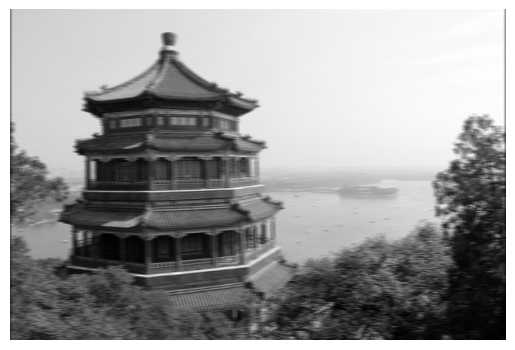

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1318s 780ms/step - accuracy: 0.6001 - loss: 1.0631 - val_accuracy: 0.8637 - val_loss: 0.3839
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1324s 770ms/step - accuracy: 0.8483 - loss: 0.4464 - val_accuracy: 0.8785 - val_loss: 0.3283
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1338s 767ms/step - accuracy: 0.8772 - loss: 0.3635 - val_accuracy: 0.8910 - val_loss: 0.3070
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1302s 771ms/step - accuracy: 0.8860 - loss: 0.3371 - val_accuracy: 0.9022 - val_loss: 0.2727
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1298s 769ms/step - accuracy: 0.9002 - loss: 0.2996 - val_accuracy: 0.9072 - val_loss: 0.2554
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
n02825657 - bell_cote - 0.82
n03877845 - palace - 0.07
n03781244 - monastery - 0.04
Epoch 1/5


In [ ]:
# ✅ Install library jika diperlukan
# !pip install tensorflow tensorflow-datasets matplotlib scikit-learn

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

##############################################
# 1️⃣ Convolution Example Using tf.nn.conv2d()
##############################################

china = load_sample_image("china.jpg") / 255.0
flower = load_sample_image("flower.jpg") / 255.0
images = np.array([china, flower], dtype=np.float32)
batch_size, height, width, channels = images.shape

# 2 filters → vertical & horizontal lines
filters = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1  # vertical line
filters[3, :, :, 1] = 1  # horizontal line

outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")
plt.imshow(outputs[0, :, :, 1], cmap="gray")  # 1st image, 2nd filter (horizontal)
plt.axis("off")
plt.show()

##############################################
# 2️⃣ Simple CNN on Fashion MNIST
##############################################

fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

model = keras.models.Sequential([
    keras.layers.Conv2D(64, 7, activation="relu", padding="same", input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(256, 3, activation="relu", padding="same"),
    keras.layers.Conv2D(256, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)

##############################################
# 3️⃣ Using Pretrained Models (Transfer Learning)
##############################################

# Example with pretrained ResNet50
resnet_model = keras.applications.resnet50.ResNet50(weights="imagenet")
sample_image = tf.image.resize(china, [224, 224]) * 255
sample_image = keras.applications.resnet50.preprocess_input(sample_image[np.newaxis, ...])

Y_proba = resnet_model.predict(sample_image)
decoded = keras.applications.resnet50.decode_predictions(Y_proba, top=3)[0]
for class_id, name, score in decoded:
    print(f"{class_id} - {name} - {score:.2f}")

##############################################
# 4️⃣ Transfer Learning Example with TFDS (Flowers Dataset)
##############################################

import tensorflow_datasets as tfds
dataset, info = tfds.load("tf_flowers", with_info=True, as_supervised=True)
n_classes = info.features["label"].num_classes

def preprocess(image, label):
    image = tf.image.resize(image, [224, 224])
    image = keras.applications.xception.preprocess_input(image)
    return image, label

batch_size = 32
train_set = dataset["train"].map(preprocess).shuffle(1000).batch(batch_size).prefetch(1)

base_model = keras.applications.xception.Xception(weights="imagenet", include_top=False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
transfer_model = keras.Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers:
    layer.trainable = False

transfer_model.compile(loss="sparse_categorical_crossentropy",
                       optimizer=keras.optimizers.SGD(learning_rate=0.2, momentum=0.9, decay=0.01),
                       metrics=["accuracy"])

history = transfer_model.fit(train_set, epochs=5)

# 📚 Chapter 14 - Deep Computer Vision Using CNNs

---

## 🔸 1. Apa Itu CNN?
**Convolutional Neural Networks (CNNs)** → arsitektur neural network yang dirancang khusus untuk memproses data gambar atau data spasial lain.

**Ciri utama CNN:**
- **Convolution layers** → mendeteksi pola lokal (edge, corner, texture)
- **Pooling layers** → menyederhanakan representasi → mengurangi ukuran data
- **Fully Connected layers** → menginterpretasikan fitur → menghasilkan prediksi

---

## 🔸 2. Operasi Convolution
- Menggunakan **filter/kernel** → dipindahkan ke seluruh gambar → menghasilkan **feature map**
- Menggunakan **padding** → agar output tetap memiliki dimensi tertentu
- **Stride** → menentukan seberapa besar langkah filter melintasi gambar

---

## 🔸 3. CNN Architectures
| Model      | Keterangan                                  |
| ---------- | ------------------------------------------- |
| **LeNet-5**| Salah satu CNN pertama → untuk digit MNIST  |
| **AlexNet**| Lebih dalam → mempopulerkan CNN untuk ImageNet |
| **GoogLeNet (Inception)** | Multi-path convolution → efisiensi  |
| **ResNet** | Residual connections → sangat dalam, stabil  |
| **Xception** | Depthwise separable convolution → efisien  |
| **SENet**  | Menambahkan perhatian channel → akurasi ↑    |

---

## 🔸 4. Data Augmentation
✅ Teknik untuk **memperbanyak variasi data** tanpa perlu menambah dataset asli:
- Rotasi
- Flip horizontal/vertical
- Zoom
- Shift posisi

→ Membantu mencegah **overfitting**.

---

## 🔸 5. Transfer Learning
Menggunakan model yang sudah dilatih (biasanya di dataset besar seperti **ImageNet**) → fine-tune untuk task baru.
- ✅ Lebih cepat
- ✅ Lebih akurat → jika dataset kecil

---

## 🔸 6. Pretrained Models in Keras
Contoh model pretrained → `ResNet50`, `Xception`, `MobileNet`, dll.
- Bisa pakai `include_top=False` → untuk menyesuaikan dengan dataset kita.
- Gunakan preprocessing yang sesuai untuk setiap model.

---

## ✅ Kesimpulan
- ✅ CNN sangat efektif untuk data gambar
- ✅ Transfer Learning = strategi praktis untuk tugas Computer Vision
- ✅ Data augmentation = wajib untuk memperkuat generalisasi model

